# Walkthrough

This walkthrough builds `immrax` from the bottom up around a single idea:
**bounding is a function transformation**. Just as JAX gives you `grad`, `jit`,
and `vmap` as transforms that take a function and return a new one, `immrax`
gives you transforms that take a function and return a *guaranteed enclosure* of
its output — and they compose with the JAX transforms. Because everything
compiles through JAX, each step below also reports its **runtime**: after a
one-time JIT compile, reachable sets and neural-network verification run in
milliseconds — the whole point of building on JAX.

We climb that ladder in six steps:

1. **Bound propagation as JAX transformations** — interval analysis
   (`natif`/`jacif`/`mjacif`) and `crown()` for neural networks.
2. **Interval reachability** — lift a dynamical `System` to its embedding and
   integrate a box, on the reverse-time Van der Pol oscillator.
3. **Parametric reachability — adjoint embeddings** — rotate/shape a polytope
   with the flow (`AdjointEmbedding`) to recover tight tubes.
4. **Parametric reachability — controlled embeddings** — *optimize* the tube
   with `ReachiLQR` when the adjoint alone isn't enough.
5. **Other set geometries** — norm-based reachable sets (`L1`/`L2`/`Linf`
   normotopes) grounded in contraction theory and the logarithmic norm.
6. **Neural-network-controlled dynamics** — fold the §1 network bounds into a
   closed-loop embedding to verify an ARCH-AINNCS benchmark.

In [1]:
import pathlib

import diffrax
import jax
import jax.numpy as jnp
import numpy as onp
from typing import ClassVar

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

import immrax as irx

# Repo root, used to locate the trained controller for §5.
REPO = pathlib.Path(irx.__file__).resolve().parents[1]

## 1. Bound Propagation as JAX Transformations

An **interval** $[\underline{x},\overline{x}]$ is the set
$\{x : \underline{x}\le x\le\overline{x}\}$. An *inclusion function* $\mathsf F$
for $f$ is any interval-to-interval map with the soundness guarantee

$$ x\in[\underline{x},\overline{x}] \;\Longrightarrow\; f(x)\in
   \mathsf F([\underline{x},\overline{x}]). $$

`immrax` represents intervals with the `Interval` pytree and provides several
*transforms* that turn an ordinary JAX function `f` into an inclusion function.

The simplest one is the **natural interval extension** `natif`: replace every
primitive with its interval counterpart and propagate. The animation shows this
compositionally for $h(x)=\sin(x^2)$ — interval bounds flow through $u=x^2$ and
then $y=\sin(u)$ to enclose the composition (computed live by `immrax`):

<video src="_static/walkthrough/bound_propagation.mp4" controls loop muted width="85%"></video>

In [2]:
ix = irx.interval(jnp.array([-1.0, 0.0]), jnp.array([1.0, 2.0]))


def f(z):
    return jnp.array([z[0] ** 2 + z[1], z[0] * z[1]])


print("natif :", irx.natif(f)(ix))   # natural interval extension
print("jacif :", irx.jacif(f)(ix))   # mean-value / Jacobian form
print("mjacif:", irx.mjacif(f)(ix))  # mixed Jacobian form

natif : [⟦0., 3.⟧ ⟦-2., 2.⟧]
jacif : [⟦-2., 4.⟧ ⟦-3., 3.⟧]
mjacif: [⟦-2., 4.⟧ ⟦-2., 2.⟧]


Each row is a sound enclosure of $f$ over the box, but they differ in
tightness, and **no single transform dominates**: on the bilinear term
$z_1 z_2$, `natif` ($[-2,2]$) beats `jacif` ($[-3,3]$), while `mjacif` combines
the two and recovers the tighter $[-2,2]$. Because these are JAX functions, you
can `jit`, `vmap`, and `grad` straight through them.

### CROWN: bound propagation for neural networks

A ReLU network is just a composition of affine maps and activations, so the
same idea applies — but instead of a box-to-box map, **CROWN** propagates
*affine* lower/upper bounds $\underline C x+\underline d \le \mathrm{net}(x)
\le \overline C x + \overline d$, conditioning each ReLU's slope on its
pre-activation sign. Keeping the linear term avoids the dependency blow-up that
plagues naive interval arithmetic through deep nets.

In [3]:
# A real trained controller: the 5-layer ACC network we verify in §6.
net = irx.NeuralNetwork(REPO / "examples/ARCH-AINNCS/ACC/controller_5_20")

# Box of the controller's inputs [v_set, T_gap, v_ego, D_rel, v_rel] at t=0.
ix_net = irx.interval(jnp.array([30.0, 1.4, 30.0, 79.0, 1.8]),
                      jnp.array([30.0, 1.4, 30.2, 100.0, 2.2]))

# crown(net) is the affine-bound transform; calling it on the box returns the
# affine bounds, and calling those on the box again returns the interval hull.
nat = irx.natif(net)(ix_net)
crn = irx.crown(net)(ix_net)(ix_net)
wn, wc = float((nat.upper - nat.lower)[0]), float((crn.upper - crn.lower)[0])
print(f"natif(net): {nat}  width {wn:.1f}")
print(f"crown(net): {crn}  width {wc:.2f}")
print(f"crown is ~{wn / wc:.0f}x tighter")

Successfully loaded model from /home/akash/Research/immrax/examples/ARCH-AINNCS/ACC/controller_5_20/model.eqx
natif(net): [⟦-1175.3348, 417.51202⟧]  width 1592.8
crown(net): [⟦-1.7051151, -0.06951013⟧]  width 1.64
crown is ~974x tighter


Through five layers, naive interval arithmetic suffers the **dependency
problem** — each layer re-bounds already-bounded quantities — and blows up to a
*vacuous* enclosure hundreds of units wide. CROWN's affine bounds stay tight,
here roughly **1000× tighter**. We fold exactly this `crown` transform into the
closed-loop embedding of §6.

## 2. Interval Reachability

To bound a *reachable set*, `immrax` lifts a continuous-time `System`
$\dot x = f(x)$ to an **embedding system** on $\mathbb R^{2n}$ whose trajectory
encloses the true reachable set at every time. The simplest embedding,
`natemb`, propagates an axis-aligned box.

Our running plant is the **reverse-time Van der Pol oscillator**

$$ \dot x_1 = -x_2, \qquad \dot x_2 = -\mu(1-x_1^2)\,x_2 + x_1, \quad \mu=1, $$

whose origin is a stable spiral — trajectories from a disk spiral inward.

In [4]:
class ReverseVanDerPol(irx.System):
    xlen: ClassVar[int] = 2
    mu: float = 1.0

    def f(self, t, x):
        x1, x2 = x
        return jnp.array([-x2, -self.mu * (1.0 - x1**2) * x2 + x1])


sys = ReverseVanDerPol()

x0 = jnp.array([1.0, 0.0])
ix0 = irx.icentpert(x0, jnp.array([0.1, 0.1]))  # box of half-width 0.1 around x0
t0, dt = 0.0, 0.01
tf2, N2 = 6.0, 600  # full horizon: the box wraps and ultimately diverges

natemb = irx.natemb(sys)
z0 = jnp.concatenate([ix0.lower, ix0.upper])
# Time it: JIT once, then report the steady-state cost (immrax's whole pitch).
reach_box = jax.jit(lambda z: natemb.compute_trajectory(t0, tf2, z, dt=dt, solver="euler").ys)
box_ys, t_box = irx.utils.run_times(11, reach_box, z0)
print(f"interval reach set: {float(jnp.mean(t_box[1:])) * 1e3:.2f} ms/run "
      f"(first call incl. JIT {float(t_box[0]):.1f}s)")

interval reach set: 0.06 ms/run (first call incl. JIT 1.4s)


In [5]:
# Monte-Carlo truth: integrate each boundary point with the system's own
# `compute_trajectory`, on the *same* solver and time grid as the reach set, so
# the samples can never drift from the enclosure in time or phase.
def mc_sweep(system, x0s, tf, N, solver="euler"):
    grid = jnp.linspace(0.0, tf, N + 1)  # the solver's step grid, shared with the set
    one = lambda x: system.compute_trajectory(
        0.0, tf, x, dt=tf / N, solver=solver, saveat=diffrax.SaveAt(ts=grid)
    ).ys
    return onp.asarray(jax.vmap(one)(x0s))


corners = jnp.array([[ix0.lower[0], ix0.lower[1]], [ix0.lower[0], ix0.upper[1]],
                     [ix0.upper[0], ix0.upper[1]], [ix0.upper[0], ix0.lower[1]]])
edge = jnp.linspace(0.0, 1.0, 25)[:, None]
boundary = jnp.concatenate(
    [(1 - edge) * corners[i] + edge * corners[(i + 1) % 4] for i in range(4)]
)
mc = mc_sweep(sys, boundary, tf2, N2, "euler")

/tmp/ipykernel_1830182/3116586868.py:11: RuntimeWarning: invalid value encountered in subtract
  width = (box_hi - box_lo).max(1)


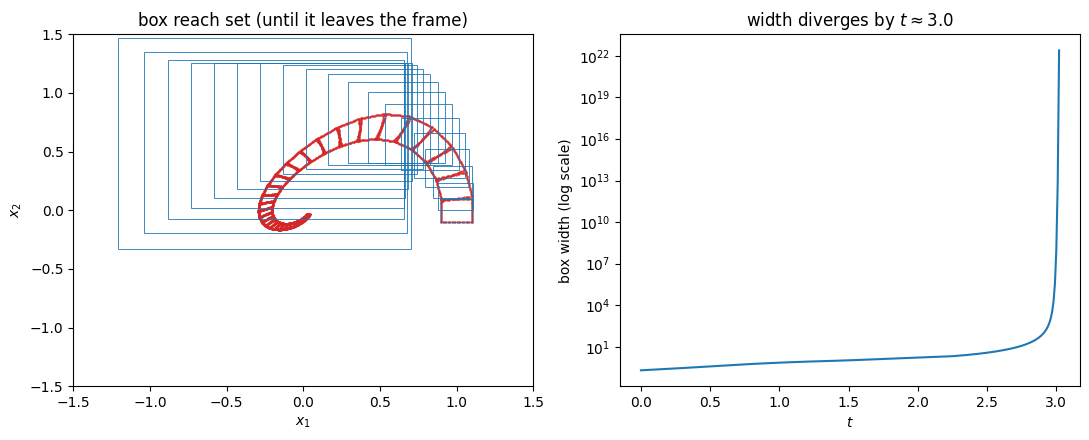

In [6]:
nx = z0.shape[0] // 2
box_lo = onp.asarray(box_ys[:, :nx])
box_hi = onp.asarray(box_ys[:, nx:])
mc_np = onp.asarray(mc)

# The box stays finite only up to its divergence; find that prefix and the time
# at which it first leaves a fixed viewport.
finite = onp.isfinite(box_lo).all(1) & onp.isfinite(box_hi).all(1)
n_box = int(onp.argmin(finite)) if not finite.all() else len(finite)
coord = onp.maximum(onp.abs(box_lo).max(1), onp.abs(box_hi).max(1))
width = (box_hi - box_lo).max(1)
VIEW = 1.5
n_view = int(onp.argmax(coord > VIEW)) if (coord[:n_box] > VIEW).any() else n_box

fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 4.5))
ax.scatter(mc_np[:, ::20, 0], mc_np[:, ::20, 1], s=0.3, color="tab:red", zorder=0)
for i in range(0, n_view, 12):
    irx.utils.draw_iarray(ax, irx.interval(box_lo[i], box_hi[i]), ec="tab:blue", lw=0.6)
ax.set_xlim(-VIEW, VIEW); ax.set_ylim(-VIEW, VIEW)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("box reach set (until it leaves the frame)")
axr.semilogy(onp.arange(n_box) * dt, width[:n_box], color="tab:blue")
axr.set_xlabel("$t$"); axr.set_ylabel("box width (log scale)")
axr.set_title(f"width diverges by $t \\approx {n_box * dt:.1f}$")
fig.tight_layout()
plt.show()

Sweeping the box forward in time — it wraps, balloons, and explodes off-frame
(red = Monte-Carlo truth, which stays small):

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
STEP = 8


def draw_box_frame(k):
    ax.clear()
    t_idx = min(k * STEP, n_box - 1)
    ax.scatter(mc_np[:, : t_idx + 1, 0], mc_np[:, : t_idx + 1, 1], s=0.3, color="tab:red")
    for i in range(0, t_idx + 1, STEP):
        irx.utils.draw_iarray(ax, irx.interval(box_lo[i], box_hi[i]), ec="tab:blue", lw=0.6)
    ax.set_xlim(-VIEW, VIEW); ax.set_ylim(-VIEW, VIEW)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"natemb box, $t = {t_idx * dt:.2f}$")


ani = animation.FuncAnimation(fig, draw_box_frame, frames=n_box // STEP + 1, interval=120)
out = HTML(ani.to_html5_video())  # render while the figure is still pyplot-managed
plt.close(fig)
out

The box always *soundly* contains the truth, but it cannot follow the flow's
*rotation*: the axis-aligned enclosure wraps, inflates, and here diverges to
infinity well before the horizon ends — even though the true trajectories
(red) stay small. This wrapping effect is exactly what parametric sets fix.

## 3. Parametric Reachability — Adjoint Embeddings

The wrapping blow-up is a limitation of the *box*, not of reachability. A
**parametope** is the more general set

$$ \{x : g(\alpha,\, x - \mathring{x}) \le y\}, $$

with a shape $\alpha$, center $\mathring{x}$, offset $y$, and a chosen
nonlinearity $g$. A **polytope** takes $g(\alpha, z) = \alpha z$ — an
intersection of halfspaces $\{x : \alpha(x-\mathring x) \le y\}$ — so an interval
box is just the polytope with $\alpha = I$ (the §2 box was already a parametope).
An **ellipsoid** (`L2Normotope`) takes $g(\alpha, z) = \lVert\alpha z\rVert_2$.

An **adjoint embedding** carries the shape $\alpha$ along the flow, rotating it
with the linearized dynamics so the set tracks the flow instead of fighting it.
For a *linear* system $\dot x = Ax$ this is **exact**: the reachable set of a
polytope is an affine image of that polytope, and the adjoint recovers it. Watch
the polytope rotate to track a spiral (blue = adjoint polytope, red = truth):

/tmp/ipykernel_1830182/1439002767.py:23: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  lin_emb = AdjointEmbedding(lin, jnp.linalg.pinv(lin_pt0.alpha), jnp.zeros((0, 2)))


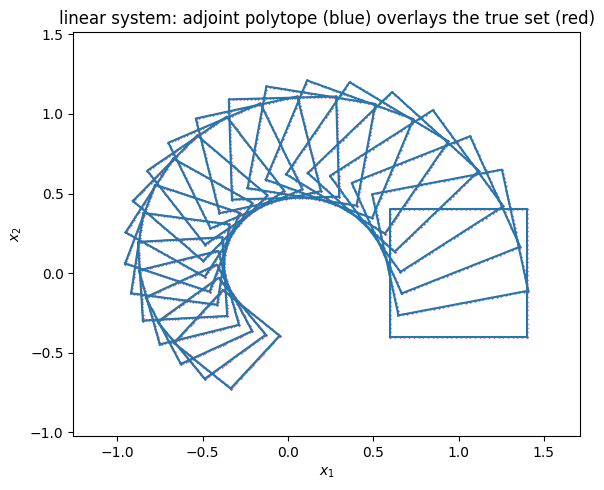

In [8]:
from immrax.parametric import AdjointEmbedding, Polytope

A_lin = jnp.array([[-0.15, -1.0], [1.0, -0.15]])


class Linear(irx.System):
    xlen: ClassVar[int] = 2

    def f(self, t, x):
        return A_lin @ x


lin = Linear()
lin_ix0 = irx.interval(jnp.array([0.6, -0.4]), jnp.array([1.4, 0.4]))
lin_pt0 = Polytope.from_interval(lin_ix0)
lin_tf, lin_N = 4.0, 400

# AdjointEmbedding needs H^+ = pinv(alpha) and a left-null basis N (empty here).
# Use tsit5: Euler's H_dot=-HA step (I-dtA) doesn't exactly invert the state step
# (I+dtA), so Euler drifts ~O(dt) over the spiral; tsit5 is accurate (the
# continuous adjoint is exact for linear systems). The MC below is integrated and
# saved on the same grid, so the two stay aligned.
lin_emb = AdjointEmbedding(lin, jnp.linalg.pinv(lin_pt0.alpha), jnp.zeros((0, 2)))
lin_rs = lin_emb.compute_reachset(0.0, lin_tf, lin_pt0, dt=lin_tf / lin_N, solver="tsit5")
lin_n = int(jnp.isfinite(lin_rs.ts).sum())
lin_yy = lin_rs.ys[0]

lc = jnp.array([[lin_ix0.lower[0], lin_ix0.lower[1]], [lin_ix0.lower[0], lin_ix0.upper[1]],
                [lin_ix0.upper[0], lin_ix0.upper[1]], [lin_ix0.upper[0], lin_ix0.lower[1]]])
le = jnp.linspace(0.0, 1.0, 30)[:, None]
lin_bnd = jnp.concatenate([(1 - le) * lc[i] + le * lc[(i + 1) % 4] for i in range(4)])
lin_mc_traj = mc_sweep(lin, lin_bnd, lin_tf, lin_N, "tsit5")  # accurate; same grid as the set


def poly_at(yy, k):
    return Polytope(yy.ox[k], yy.alpha[k], yy.y[k])


def draw_polytope(ax, pt, **kw):  # plot the closed polygon directly (no plt.sca)
    try:
        V = onp.asarray(pt.get_vertices())
    except Exception:
        return
    if len(V) < 3 or not onp.isfinite(V).all():
        return
    c = V.mean(0)
    V = V[onp.argsort(onp.arctan2(V[:, 1] - c[1], V[:, 0] - c[0]))]
    V = onp.vstack([V, V[0]])
    ax.plot(V[:, 0], V[:, 1], **kw)


XLIM_L = (lin_mc_traj[:, :, 0].min() - 0.3, lin_mc_traj[:, :, 0].max() + 0.3)
YLIM_L = (lin_mc_traj[:, :, 1].min() - 0.3, lin_mc_traj[:, :, 1].max() + 0.3)

EVERY_L = 20  # same stride for the tube and the MC so red sits on each blue set
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lin_mc_traj[:, ::EVERY_L, 0], lin_mc_traj[:, ::EVERY_L, 1], s=0.3, color="tab:red", zorder=0)
for k in range(0, lin_n, EVERY_L):
    draw_polytope(ax, poly_at(lin_yy, k), color="tab:blue")
ax.set_xlim(*XLIM_L); ax.set_ylim(*YLIM_L)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("linear system: adjoint polytope (blue) overlays the true set (red)")
fig.tight_layout()
plt.show()

The polytope rotates with the flow and overlays the truth exactly — no wrapping.
Animated:

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
LSTEP = 8


def lin_frame(k):
    ax.clear()
    t_idx = min(k * LSTEP, lin_n - 1)
    ax.scatter(lin_mc_traj[:, : t_idx + 1 : 4, 0], lin_mc_traj[:, : t_idx + 1 : 4, 1],
               s=0.3, color="tab:red")
    draw_polytope(ax, poly_at(lin_yy, t_idx), color="tab:blue")
    ax.set_xlim(*XLIM_L); ax.set_ylim(*YLIM_L)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"linear adjoint polytope, $t = {t_idx * (lin_tf / lin_N):.2f}$")


ani = animation.FuncAnimation(fig, lin_frame, frames=lin_n // LSTEP + 1, interval=120)
out = HTML(ani.to_html5_video())  # render while the figure is still pyplot-managed
plt.close(fig)
out

### The same idea on the nonlinear Van der Pol

Adjoint embeddings work for any system. On the reverse-time VDP a **polytope**
(a rotated box) carried by `AdjointEmbedding` tracks the nonlinear flow far
better than the §2 axis-aligned box. For a small initial set — the *same* box
that exploded in §2 — it stays tight across the whole horizon:

/tmp/ipykernel_1830182/4012490227.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  e = AdjointEmbedding(sys, jnp.linalg.pinv(pt0.alpha), jnp.zeros((0, pt0.alpha.shape[0])))
/tmp/ipykernel_1830182/4012490227.py:18: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  _emb_s = AdjointEmbedding(sys, jnp.linalg.pinv(pt_small.alpha), jnp.zeros((0, 2)))


polytope adjoint reach set: 0.09 ms/run (first call incl. JIT 2.2s)


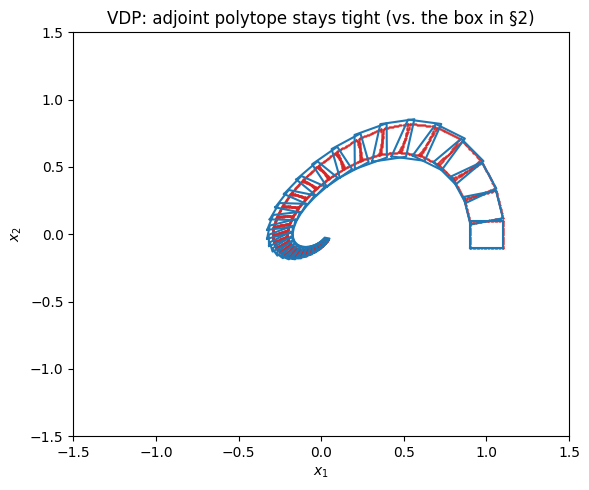

In [10]:
def adj_poly_reach(pt0, tf, N):
    e = AdjointEmbedding(sys, jnp.linalg.pinv(pt0.alpha), jnp.zeros((0, pt0.alpha.shape[0])))
    rs = e.compute_reachset(0.0, tf, pt0, dt=tf / N, solver="euler")
    return rs, int(jnp.isfinite(rs.ts).sum())


def box_boundary(c, hw, m=25):
    lo, hi = c - hw, c + hw
    cor = jnp.array([[lo[0], lo[1]], [lo[0], hi[1]], [hi[0], hi[1]], [hi[0], lo[1]]])
    e = jnp.linspace(0.0, 1.0, m)[:, None]
    return jnp.concatenate([(1 - e) * cor[i] + e * cor[(i + 1) % 4] for i in range(4)])


pt_small = Polytope.from_interval(ix0)  # the half-width 0.1 box from §2
rs_ps, n_ps = adj_poly_reach(pt_small, 6.0, 600)

# Parametric reachability is just as fast — JIT once, then time the steady state.
_emb_s = AdjointEmbedding(sys, jnp.linalg.pinv(pt_small.alpha), jnp.zeros((0, 2)))
reach_poly = jax.jit(lambda p: _emb_s.compute_reachset(0.0, 6.0, p, dt=0.01, solver="euler").ys[0].alpha)
_, t_poly = irx.utils.run_times(11, reach_poly, pt_small)
print(f"polytope adjoint reach set: {float(jnp.mean(t_poly[1:])) * 1e3:.2f} ms/run "
      f"(first call incl. JIT {float(t_poly[0]):.1f}s)")

EVERY = 20  # same stride for the tube and the MC so red sits in each blue set
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mc[:, ::EVERY, 0], mc[:, ::EVERY, 1], s=0.3, color="tab:red", zorder=0)  # §2 MC, same box
for k in range(0, n_ps, EVERY):
    draw_polytope(ax, poly_at(rs_ps.ys[0], k), color="tab:blue")
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("VDP: adjoint polytope stays tight (vs. the box in §2)")
fig.tight_layout()
plt.show()

Swept forward in time — the same form as the §2 box, but the polytope rotates
with the flow so the tube stays tight instead of exploding:

In [11]:
def time_sweep_poly(poly_at_k, n, mc_arr, xlim, ylim, color, title):
    """Cumulative reach-tube animation over time (the §2 box form), for polytopes."""
    fig, ax = plt.subplots(figsize=(6, 5))
    step = max(1, n // 50)

    def frame(j):
        ax.clear()
        ti = min(j * step, n - 1)
        ax.scatter(mc_arr[:, : ti + 1, 0], mc_arr[:, : ti + 1, 1], s=0.3, color="tab:red")
        for k in range(0, ti + 1, step):
            draw_polytope(ax, poly_at_k(k), color=color)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
        ax.set_title(f"{title}, $t = {ti * dt:.2f}$")

    ani = animation.FuncAnimation(fig, frame, frames=n // step + 1, interval=120)
    out = HTML(ani.to_html5_video())
    plt.close(fig)
    return out


time_sweep_poly(lambda k: poly_at(rs_ps.ys[0], k), n_ps, mc_np,
                (-1.5, 1.5), (-1.5, 1.5), "tab:blue", "VDP adjoint polytope")

But the adjoint only *linearizes* the flow, so it cannot capture the nonlinear
bending of a *larger* set. Double the box to half-width $0.2$ and the polytope
inflates and diverges partway through the horizon:

In [12]:
def poly_area(pt):
    V = onp.asarray(pt.get_vertices())
    c = V.mean(0)
    V = V[onp.argsort(onp.arctan2(V[:, 1] - c[1], V[:, 0] - c[0]))]
    return 0.5 * abs(sum(V[i, 0] * V[(i + 1) % len(V), 1] - V[(i + 1) % len(V), 0] * V[i, 1]
                         for i in range(len(V))))


pt_big = Polytope.from_interval(irx.icentpert(x0, 0.2 * jnp.ones(2)))
rs_pb, n_pb = adj_poly_reach(pt_big, 6.0, 600)
a0 = poly_area(poly_at(rs_pb.ys[0], 0))
n_valid = n_pb
for k in range(n_pb):
    a = poly_area(poly_at(rs_pb.ys[0], k))
    if not onp.isfinite(a) or a > 50 * a0:
        n_valid = k
        break
print(f"adjoint polytope (half-width 0.2) stays tight only to step {n_valid}/600 "
      f"(t ~ {n_valid * dt:.1f}) before the nonlinear residual blows it up.")

/tmp/ipykernel_1830182/4012490227.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  e = AdjointEmbedding(sys, jnp.linalg.pinv(pt0.alpha), jnp.zeros((0, pt0.alpha.shape[0])))


adjoint polytope (half-width 0.2) stays tight only to step 231/600 (t ~ 2.3) before the nonlinear residual blows it up.


## 4. Parametric Reachability — Controlled Embeddings

When the adjoint alone can't keep a large set bounded, we add a **control** to
the embedding itself. `ReachiLQR` treats the per-timestep shape matrix $H$ as a
control input and runs iterative LQR over the embedding to minimize the tube's
log-volume. A `Jmax` cap freezes any step whose set exceeds a target volume;
iLQR's job is to bend the whole horizon back under the cap.

We take the same half-width-$0.2$ polytope the adjoint above could not hold. The
schedule first **pushes** the horizon out (heavy damping $R=200$, reverting to
the best at the phase boundary), then **locks** it in and tightens ($R=1000$):

In [40]:
from immrax.parametric import ReachiLQR, phased_schedule

N, Jmax, tf3 = 600, -2.0, 6.0
poly_pt0 = Polytope.from_interval(irx.icentpert(x0, 0.2 * jnp.ones(2)))


def terminal_cost(pt):  # negative log-volume of the polytope
    K = len(pt.y) // 2
    s = (pt.y[K:] + pt.y[:K]) / 2  # per-facet half-width
    A = pt.alpha / s[:, None]
    # The shape matrix A is a general invertible matrix, not SPD, so we take the
    # log-volume of the SPD Gram A^T A via Cholesky (stabler than slogdet).
    L = jnp.linalg.cholesky(A.T @ A)
    return -2.0 * jnp.sum(jnp.log(jnp.diag(L)))


def running_cost(t, pt, U):
    return jnp.array(0.0)  # R enters as Levenberg-Marquardt damping on Quu


ilqr = ReachiLQR(
    embedding=AdjointEmbedding(sys, jnp.linalg.inv(poly_pt0.alpha), jnp.zeros((0, 2))),
    pt0=poly_pt0, terminal_cost=terminal_cost, running_cost=running_cost,
    t0=t0, tf=tf3, N=N, dt=tf3 / N, track_iover=True,
)
_, t_jit = irx.utils.run_times(1, ilqr.setup)  # one-off JIT compile

# Iterate 0 with zero control == the plain adjoint polytope rollout (baseline).
base = ilqr.iterate(ilqr.initial_controls(), *ilqr.initial_gains(), 200.0, gamma=0.5, Jmax=Jmax)

# Phase 1 (R=100): initially low regularization, reset to best in first phase
# Phase 2 (R=1000): high regularization improves cost. 
schedule = phased_schedule([(100.0, False, 39), (100.0, True, 1), (1000.0, False, 20)])

# Record the per-iteration history
hist = []
def record(i, R, res):
    hist.append((int(res.ifinal), float(res.cost_final)))


res, t_run = irx.utils.run_times(
    1, lambda: ilqr.run(R_schedule=schedule, gamma=0.5, Jmax=Jmax, on_iterate=record, verbose=True)
)
print(f"baseline (adjoint only): reaches step {int(base.ifinal)}/{N}, cost {float(base.cost_final): .2f}")
print(f"after ReachiLQR        : reaches step {int(res.best.ifinal)}/{N}, cost {float(res.best.cost_final): .2f}")
print(f"runtime: {float(t_jit[0]):.1f}s JIT compile + {float(t_run[0]):.1f}s for {schedule.total} iterations")

/tmp/ipykernel_1830182/2434671470.py:22: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  embedding=AdjointEmbedding(sys, jnp.linalg.inv(poly_pt0.alpha), jnp.zeros((0, 2))),


i=    0  R=     100  ifinal=  191  cost=-2.0281
i=    1  R=     100  ifinal=  219  cost=-2.0400
i=    2  R=     100  ifinal=  230  cost=-2.0178
i=    3  R=     100  ifinal=  247  cost=-2.0473
i=    4  R=     100  ifinal=  296  cost=-2.0092
i=    5  R=     100  ifinal=  380  cost=-2.0498
i=    6  R=     100  ifinal=   97  cost=-2.0728
i=    7  R=     100  ifinal=   98  cost=-2.0112
i=    8  R=     100  ifinal=  100  cost=-2.0354
i=    9  R=     100  ifinal=  102  cost=-2.0683
i=   10  R=     100  ifinal=  105  cost=-2.0144
i=   11  R=     100  ifinal=  107  cost=-2.0517
i=   12  R=     100  ifinal=  110  cost=-2.0107
i=   13  R=     100  ifinal=  113  cost=-2.0010
i=   14  R=     100  ifinal=  116  cost=-2.0118
i=   15  R=     100  ifinal=  119  cost=-2.0442
i=   16  R=     100  ifinal=  124  cost=-2.0012
i=   17  R=     100  ifinal=  129  cost=-2.0316
i=   18  R=     100  ifinal=  136  cost=-2.0212
i=   19  R=     100  ifinal=  150  cost=-2.0108
i=   20  R=     100  ifinal=  210  cost=

`ReachiLQR` recovers the **full horizon** and tightens far past the adjoint — the
blow-up was a property of the *uncontrolled* embedding, not the system. Baseline
(blue, frozen where it blew up) vs. the optimized polytope tube (green, full
horizon), against the Monte-Carlo truth (red):

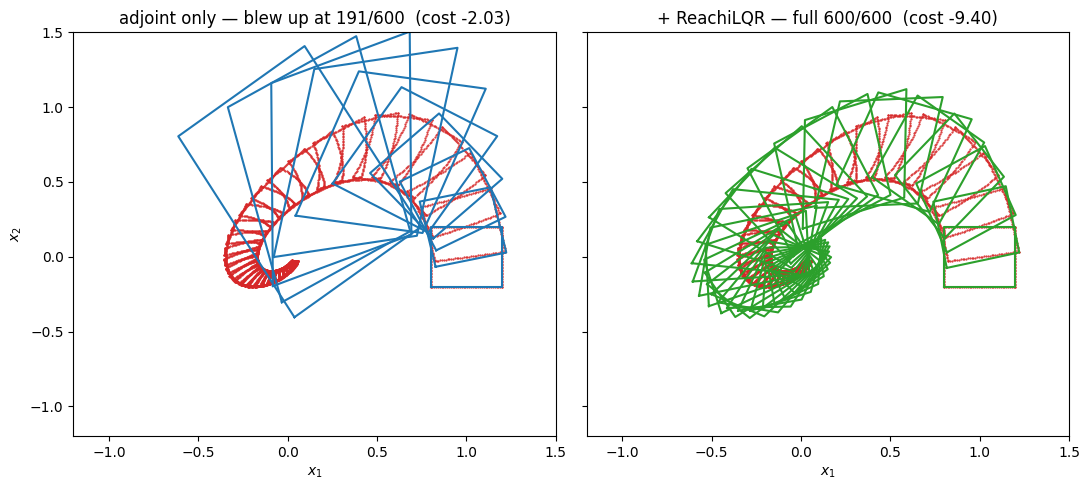

In [36]:
mc_poly = mc_sweep(sys, box_boundary(x0, 0.2, 40), tf3, N, "euler")
XLIM4, YLIM4 = (-1.2, 1.5), (-1.2, 1.5)


def draw_poly_tube(ax, pert_traj, ifinal, color, every=20):  # match the MC stride
    for j in range(0, int(ifinal), every):
        pt, _aux = ilqr._unflatten(jnp.asarray(pert_traj[j]))
        draw_polytope(ax, pt, color=color)


fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
panels = [(f"adjoint only — blew up at {int(base.ifinal)}/{N}", base, "tab:blue"),
          (f"+ ReachiLQR — full {int(res.best.ifinal)}/{N}", res.best, "tab:green")]
for ax, (lab, r, col) in zip(axs, panels):
    ax.scatter(mc_poly[:, ::20, 0], mc_poly[:, ::20, 1], s=0.3, color="tab:red", zorder=0)
    draw_poly_tube(ax, r.pert_traj, r.ifinal, col)
    ax.set_title(f"{lab}  (cost {float(r.cost_final):.2f})")
    ax.set_xlim(XLIM4); ax.set_ylim(YLIM4); ax.set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

Horizon reached and log-volume cost over iterations — phase 1 ($R=200$) walks the
horizon out, then phase 2 ($R=1000$) locks it and drives the volume down:

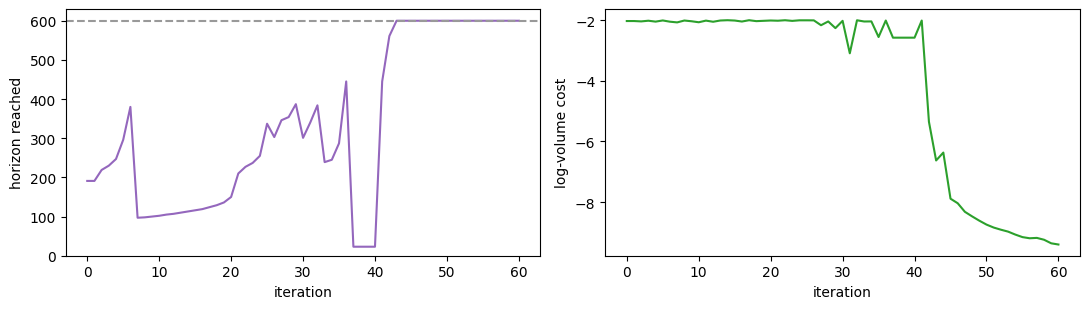

In [37]:
ifin_hist = [int(base.ifinal)] + [h[0] for h in hist]
cost_hist = [float(base.cost_final)] + [h[1] for h in hist]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.plot(ifin_hist, color="tab:purple"); a1.axhline(N, ls="--", color="0.6")
a1.set_xlabel("iteration"); a1.set_ylabel("horizon reached"); a1.set_ylim(0, N + 30)
a2.plot(cost_hist, color="tab:green")
a2.set_xlabel("iteration"); a2.set_ylabel("log-volume cost")
fig.tight_layout()
plt.show()

And the optimized tube swept forward in time (the same form as §2) — it now
forms cleanly across the full horizon, staying tight to the truth:

In [38]:
best_sv = onp.asarray(res.best.pert_traj)


def best_poly_at(k):
    pt, _aux = ilqr._unflatten(jnp.asarray(best_sv[k]))
    return pt


time_sweep_poly(best_poly_at, int(res.best.ifinal), mc_poly,
                XLIM4, YLIM4, "tab:green", "ReachiLQR polytope")

## 5. Other Set Geometries

Polytopes and ellipsoids are two points in a broader design space. `immrax`
supports **norm-based reachable sets** out of the box — `L1Normotope`,
`L2Normotope`, `LinfNormotope` — whose offset dynamics come from **contraction
theory**: the set's norm grows at a rate bounded by the **logarithmic norm**
(matrix measure) $\mu(\partial f)$ of the flow's Jacobian. Choosing the norm
chooses the geometry; the same `NormotopeEmbedding` (and `ReachiLQR`) applies.

The same VDP reachable set, carried in three different norm geometries:

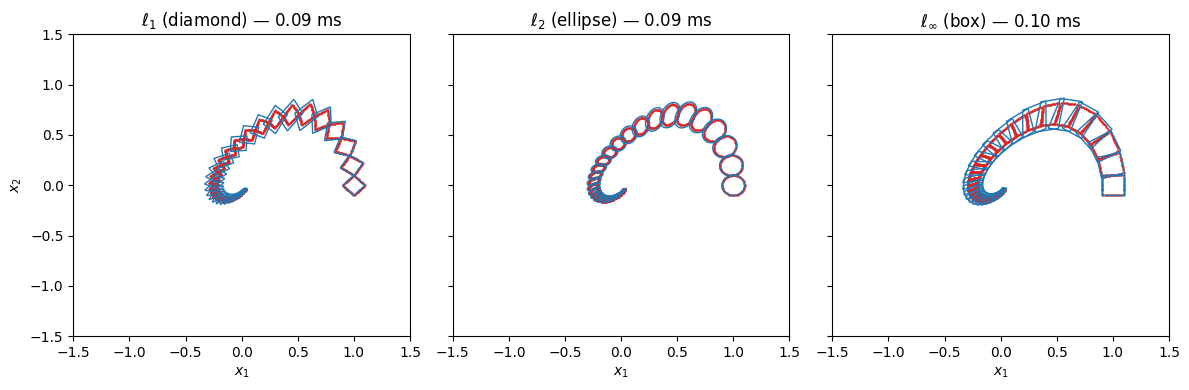

In [17]:
from immrax.utils import get_corners


def ball_boundary(cls, ox, r, m=80):  # points on the norm's unit ball, scaled to radius r
    th = jnp.linspace(0.0, 2 * jnp.pi, m, endpoint=False)
    u = jnp.stack([jnp.cos(th), jnp.sin(th)], 1)
    if cls is irx.L1Normotope:
        z = u / jnp.sum(jnp.abs(u), 1, keepdims=True)
    elif cls is irx.LinfNormotope:
        z = u / jnp.max(jnp.abs(u), 1, keepdims=True)
    else:
        z = u
    return ox + r * z


geoms = [(r"$\ell_1$ (diamond)", irx.L1Normotope, get_corners),
         (r"$\ell_2$ (ellipse)", irx.L2Normotope, None),
         (r"$\ell_\infty$ (box)", irx.LinfNormotope, get_corners)]

EVERY = 20  # same stride for the tube and the MC so red sits in each blue set
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, (name, cls, gsc) in zip(axs, geoms):
    nt0 = cls(x0, jnp.eye(2) / 0.1, 1.0)
    emb = irx.NormotopeEmbedding(sys, gsc=gsc)
    reach = jax.jit(lambda p, e=emb: e.compute_reachset(0.0, 6.0, p, dt=dt, solver="euler").ys[0].alpha)
    _, t_g = irx.utils.run_times(11, reach, nt0)
    rs = emb.compute_reachset(t0, 6.0, nt0, dt=dt, solver="euler")
    ng = int(jnp.isfinite(rs.ts).sum())
    mc_g = mc_sweep(sys, ball_boundary(cls, x0, 0.1), 6.0, 600, "euler")  # MC from this ball
    ax.scatter(mc_g[:, ::EVERY, 0], mc_g[:, ::EVERY, 1], s=0.3, color="tab:red", zorder=0)
    for k in range(0, ng, EVERY):
        cls(rs.ys[0].ox[k], rs.ys[0].alpha[k], rs.ys[0].y[k]).plot_projection(ax, color="tab:blue")
    ax.set_title(f"{name} — {float(jnp.mean(t_g[1:])) * 1e3:.2f} ms")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
fig.tight_layout()
plt.show()

Each norm gives a different — and differently tight — certified tube, all from a
one-line embedding swap. `ReachiLQR` optimizes over any of them just as it did
over the polytope in §4.

## 6. Neural-Network-Controlled Dynamics

Finally we close the loop — and the reachability of a network-controlled system
turns out to be just the §1 transforms *composed*: bound the plant with `natif`,
bound the controller with `crown`, and wire them together with `embed`. We make
that composition explicit on the ARCH-AINNCS **Adaptive Cruise Control**
benchmark.

An ego car follows a lead car that suddenly brakes ($a_{\text{lead}}=-2$); the
5-layer network from §1 sets the ego acceleration. The safety spec is no
collision with margin,
$D_{\text{rel}} \ge D_{\text{safe}} = D_{\text{def}} + T_{\text{gap}}\,
v_{\text{ego}}$, over a 5 s horizon.

In [18]:
vset, Ddefault, Tgap = 30.0, 10.0, 1.4


class ACC(irx.System):
    xlen: ClassVar[int] = 6  # [x, v, a] for lead and ego

    def f(self, t, x, u, w):
        mu, a_lead, a_ego = 1e-4, -2.0, u[0]
        x1, x2, x3, x4, x5, x6 = x
        return jnp.array([x2, x3, -2 * x3 + 2 * a_lead - mu * x2**2,
                          x5, x6, -2 * x6 + 2 * a_ego - mu * x5**2])


olsys = ACC()


def controller(x):  # the network's inputs are derived from the raw state
    vego, Drel, vrel = x[4], x[0] - x[3], x[1] - x[4]
    return net(jnp.array([vset, Tgap, vego, Drel, vrel]))


controller.out_len = 1
clsys = irx.NNCSystem(olsys, controller)

acc_ix0 = irx.interval([90.0, 32.0, 0.0, 10.0, 30.0, 0.0],
                       [110.0, 32.2, 0.0, 11.0, 30.2, 0.0])
acc_t0, acc_dt, acc_tf = 0.0, 0.05, 5.0
n_steps = round((acc_tf - acc_t0) / acc_dt) + 1


@jax.jit
def acc_reach(ix0):
    verifier = irx.crown(controller, iterated=True)  # §1's crown, on the controller
    F_plant = irx.natif(olsys.f)                      # §1's natif, on the plant

    class ClosedLoopEmbedding(irx.EmbeddingSystem):
        def __init__(self):
            self.sys = clsys
            self.xlen = 12
            self.evolution = "continuous"

        def E(self, t, x):
            ix = irx.ut2i(x)
            u_bound = verifier(ix)  # affine CROWN bound on the control input
            F = lambda t, ix: F_plant(t, ix, u_bound(ix), irx.izeros(1))
            return irx.embed(F)(t, irx.i2ut(ix))

    traj = ClosedLoopEmbedding().compute_trajectory(
        acc_t0, acc_tf, irx.i2ut(ix0), dt=acc_dt, solver="tsit5"
    )
    lead = irx.interval(traj.ys[:n_steps, 0:3], traj.ys[:n_steps, 6:9])
    ego = irx.interval(traj.ys[:n_steps, 3:6], traj.ys[:n_steps, 9:12])
    Drel = lead[:, 0] - ego[:, 0]
    Dsafe = ego[:, 1] * Tgap + Ddefault
    safe = jax.vmap(irx.utils.check_containment, (0, None))(
        Drel - Dsafe, irx.interval(0.0, jnp.inf)
    )
    return traj, Drel, Dsafe, jnp.all(safe == 1)


# Time it the ARCH-COMP way: JIT once, then the steady-state per-reach-set cost.
(traj, Drel, Dsafe, safe), t_acc = irx.utils.run_times(11, acc_reach, acc_ix0)
print("safe-distance spec D_rel >= D_safe:", "VERIFIED" if bool(safe) else "VIOLATED")
print(f"min certified margin D_rel - D_safe = {float(jnp.min(Drel.lower - Dsafe.upper)):.2f}")
print(f"runtime: {float(jnp.mean(t_acc[1:])) * 1e3:.1f} ms/reach-set "
      f"(first call incl. JIT {float(t_acc[0]):.1f}s)")

safe-distance spec D_rel >= D_safe: VERIFIED
min certified margin D_rel - D_safe = 17.16
runtime: 175.9 ms/reach-set (first call incl. JIT 7.9s)


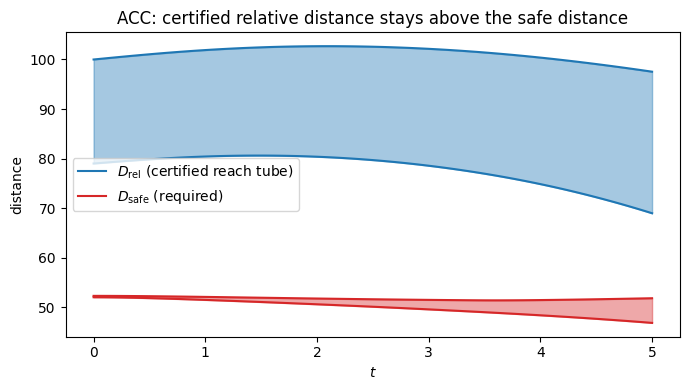

In [19]:
tt = traj.ts[:n_steps]
fig, ax = plt.subplots(figsize=(7, 4))
irx.utils.plot_interval_t(ax, tt, Drel, color="tab:blue", alpha=0.4)
irx.utils.plot_interval_t(ax, tt, Dsafe, color="tab:red", alpha=0.4)
ax.plot([], [], color="tab:blue", label=r"$D_{\rm rel}$ (certified reach tube)")
ax.plot([], [], color="tab:red", label=r"$D_{\rm safe}$ (required)")
ax.set_xlabel("$t$"); ax.set_ylabel("distance"); ax.legend()
ax.set_title("ACC: certified relative distance stays above the safe distance")
fig.tight_layout()
plt.show()

The certified relative-distance band (blue) stays entirely above the required
safe distance (red) for the full horizon, so the closed-loop system is verified
collision-free — computed by composing the very same `natif` and `crown`
transforms from §1.

## Where to go next

Every layer here was a *transformation*: an inclusion function bounds $f$, an
embedding bounds the flow, `ReachiLQR` optimizes the bounding tube, and CROWN
bounds the controller inside the loop — all composable with `jit`/`grad`/`vmap`.

- **Examples** — full runnable case studies: `examples/iLQR/` (synthesis),
  `examples/ARCH-AINNCS/` (neural verification), `examples/vehicle/`,
  `examples/pendulum/`.
- **API reference** — module-by-module docs for `inclusion`, `system`,
  `embedding`, `parametric`, `neural`.